In [1]:
from scr.qsvdd_core.circuits import QSVDDCircuit
from scr.qsvdd_core.engine import QuantumEngine
import numpy as np
from qiskit import transpile, QuantumCircuit
from qclib.util import get_cnot_count
import pennylane as qml
from matplotlib import pyplot as plt

In [2]:
n_qubits = 8
amplitudes = np.random.rand(32)
amplitudes /= np.linalg.norm(amplitudes)
# amplitudes = np.pad(amplitudes, (0, 32 - len(amplitudes)), mode='constant')
params = np.random.rand(375)
print(amplitudes)

[0.21519317 0.09110656 0.08871912 0.06709517 0.1582164  0.21165207
 0.12537143 0.11167918 0.26895967 0.1840553  0.00958524 0.31374746
 0.15147856 0.09644084 0.08118049 0.29038717 0.31397225 0.27461393
 0.02634552 0.01024167 0.01248081 0.19337812 0.10194    0.18900403
 0.27459553 0.08804593 0.00191573 0.11769456 0.26717843 0.15891171
 0.04054112 0.23096752]


In [3]:
n_qubits = 8 # 5 for Credit Card, 8 for MNIST/FMNIST
n_features = 2**n_qubits

amplitudes = np.random.rand(n_features)
amplitudes /= np.linalg.norm(amplitudes)

params_map = {
    "qcnn": 375,
    "lcqhnn": 8,
    "qae": 78
}

print(f"--- Extracting Hardware metrics for {n_qubits} Qubits ---")

for ansatz in ["qcnn", "qae", "lcqhnn"]:

    dev = qml.device('default.qubit', wires=n_qubits)

    @qml.qnode(dev)
    def check_circuit(amplitude_array, params_array):
        q_circuit = QSVDDCircuit(n_qubits)
        q_circuit.qc_complete_design(amplitude_array, params_array, f_method="pennylane", ansatz_type=ansatz)
        return qml.state()

    specs_function = qml.specs(check_circuit)

    n_params = params_map[ansatz]
    params = np.random.rand(n_params)

    specs = specs_function(amplitudes, params)
    resources = specs["resources"]

    gate_types = resources.gate_types

    n_cnots = gate_types.get("CNOT", 0)
    n_czs = gate_types.get("CZ", 0)
    total_entangling = n_cnots + n_czs

    depth = resources.depth

    print(f"{ansatz.upper():<8} -> 2-Qubit Gates (CNOT/CZ): {total_entangling:<4} | Depth: {depth}")

--- Extracting Hardware metrics for 8 Qubits ---
QCNN     -> 2-Qubit Gates (CNOT/CZ): 75   | Depth: 64
QAE      -> 2-Qubit Gates (CNOT/CZ): 243  | Depth: 119
LCQHNN   -> 2-Qubit Gates (CNOT/CZ): 14   | Depth: 17


In [4]:
print(qml.io.plugin_converters.keys())

dict_keys([])


In [5]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

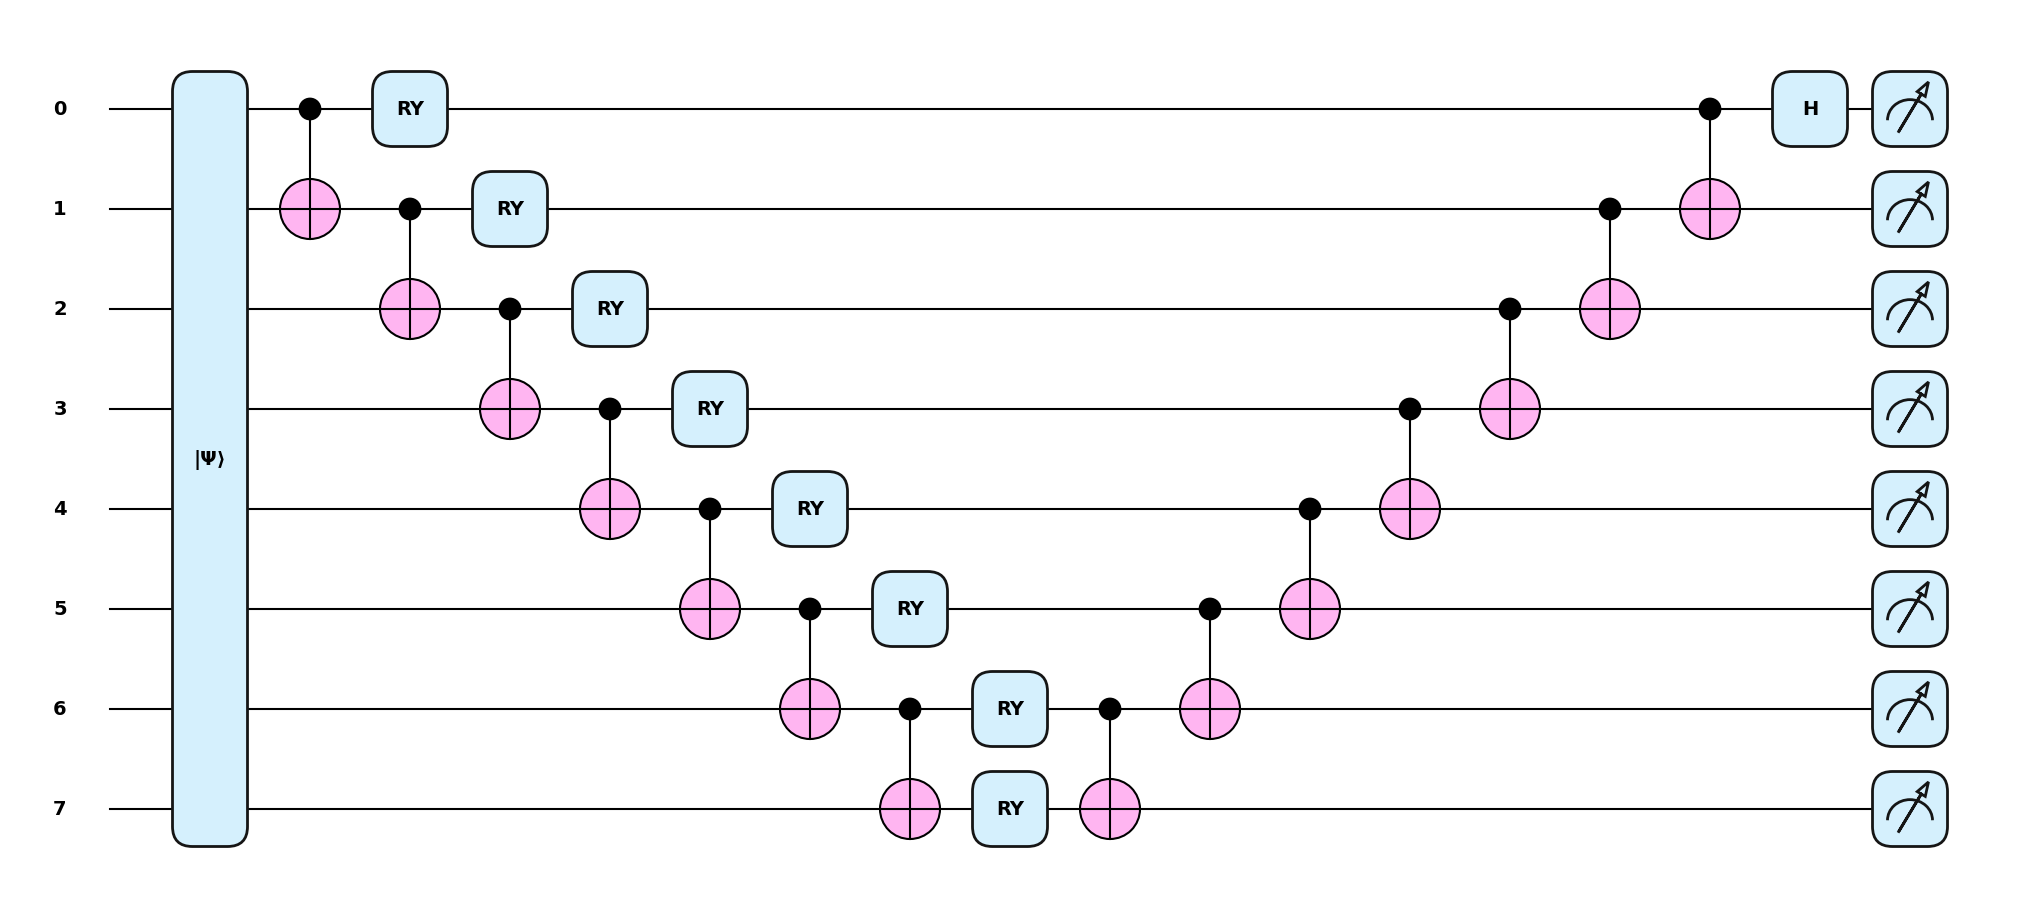

In [6]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_circuit(amplitude_array, params):
    q_circuit = QSVDDCircuit(n_qubits)
    q_circuit.qc_complete_design(amplitude_array, params, f_method="pennylane")
    return qml.state()

qml.drawer.use_style("pennylane")
fig, ax = qml.draw_mpl(check_circuit)(amplitudes, params)

plt.show()

In [7]:
dev_bench = qml.device('default.qubit', wires=n_qubits)

def get_specs_for_method(method_name, amplitudes):
    """Generates a temporary QNode to extract metrics for a specific method."""
    @qml.qnode(dev_bench)
    def temp_circuit():
        q_circuit = QSVDDCircuit(n_qubits=n_qubits)
        mapping_fn = q_circuit.feature_mapping(amplitudes, method=method_name)
        mapping_fn(wires=range(5))
        return qml.state()

    info = qml.specs(temp_circuit)()
    return info["resources"]

# --- Benchmark Execution ---

methods_map = {
    "BAA LowRank":          "baa_lowrank",
    "Bidirectional":        "bdsp",
    "Divide and Conquer":   "dcsp",
    "Isometry":             "isometry",
    "Qiskit Native":        "qiskit",
    "UCGE":                 "ucge",
}

header = f" QUANTUM FEATURE MAPPING BENCHMARKS "
print(f"\n{header:=^75}")
print(f"{'Method Strategy':<25} | {'CNOTs':>8} | {'Depth':>8} | {'Total Gates':>12}")
print("-" * 75)

all_results = {}

for name, method_key in methods_map.items():
    try:
        res = get_specs_for_method(method_key, amplitudes)
        all_results[name] = res

        # Search for CNOT or CX in the gate types dictionary
        cnot_count = res.gate_types.get("CNOT", 0) + res.gate_types.get("CX", 0)

        print(f"{name:<25} | {cnot_count:>8} | {res.depth:>8} | {res.num_gates:>12}")
    except Exception as e:
        print(f"{name:<25} | Error processing method: {str(e)[:30]}...")

print("-" * 75)


=================== QUANTUM FEATURE MAPPING BENCHMARKS ====================
Method Strategy           |    CNOTs |    Depth |  Total Gates
---------------------------------------------------------------------------
BAA LowRank               | Error processing method: Conversion from Qiskit require...
Bidirectional             | Error processing method: Conversion from Qiskit require...
Divide and Conquer        | Error processing method: Conversion from Qiskit require...
Isometry                  | Error processing method: Conversion from Qiskit require...
Qiskit Native             | Error processing method: Conversion from Qiskit require...
UCGE                      | Error processing method: Conversion from Qiskit require...
---------------------------------------------------------------------------


In [ ]:
# --- Gate Breakdown ---
print(f"\n{' GATE BREAKDOWN BY METHOD ':-^75}")

for name, res in all_results.items():
    gates_str = ", ".join([f"{gate}({count})" for gate, count in res.gate_types.items()])
    print(f"- {name:<23} -> {gates_str}")

print("=" * 75)

In [ ]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_ansatz_circuit(params):
    q_circuit = ProposedVQC(n_qubits)
    q_circuit.proposed_ansatz(params)
    return qml.state()


qml.drawer.use_style("pennylane")
fig, ax = qml.draw_mpl(check_ansatz_circuit)(params)
fig.set_size_inches(10, 5)
plt.show()

In [ ]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_feature_mapping_circuit(amplitude_array):
    q_circuit = QSVDDCircuit(n_qubits)
    mapping_fn = q_circuit.feature_mapping(amplitude_array, method="baa_lowrank")
    mapping_fn(wires=range(n_qubits))
    return qml.state()

qml.drawer.use_style("pennylane")
fig, ax = qml.draw_mpl(check_feature_mapping_circuit)(amplitudes)

plt.show()

In [10]:
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def cost_circuit(data):
    qml.AmplitudeEmbedding(data, wires=range(n_qubits), normalize=True)
    return qml.state()

tape = qml.workflow.construct_tape(cost_circuit)(amplitudes)

expanded_tape = tape.expand(
    depth=5,
    stop_at=lambda obj: obj.name in ["CNOT", "RY", "RZ", "RX"]
)

gate_counts = {}
for op in expanded_tape.operations:
    gate_counts[op.name] = gate_counts.get(op.name, 0) + 1

print("--- Actual Count (Decomposed) ---")
for gate, count in gate_counts.items():
    print(f"{gate}: {count}")

--- Actual Count (Decomposed) ---
RY: 255
CNOT: 254
